# 💳 Credit Card Fraud Detection
### Fintech ML Portfolio Project

**Objective:** Build a binary classifier to detect fraudulent credit card transactions, aligned with MFSA AML monitoring requirements for Malta-licensed financial institutions.

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
284,807 anonymised European cardholder transactions | Fraud rate: ~0.17%

---
## Project Structure
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Class Imbalance Handling
4. Model Training (Logistic Regression → Random Forest → XGBoost)
5. Evaluation (AUC-ROC, Precision, Recall, F1)
6. Explainability with SHAP
7. Threshold Tuning for Business Use
8. Conclusions & Next Steps

In [1]:
import os
os.makedirs('../outputs', exist_ok=True)

---
## 1. Setup & Data Loading

In [2]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
# Download creditcard.csv from Kaggle and place it in the ../data/ folder
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

df = pd.read_csv(r"C:\Users\franc\Desktop\DATA ANALYSIS PORTFOLIO\Fraud Detection Project\data\creditcard.csv")

print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 2. Exploratory Data Analysis (EDA)

In [4]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum().sum(), 'missing values')
print('\n=== Class Distribution ===')
fraud_counts = df['Class'].value_counts()
print(fraud_counts)
print(f'\nFraud rate: {fraud_counts[1] / len(df) * 100:.3f}%')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

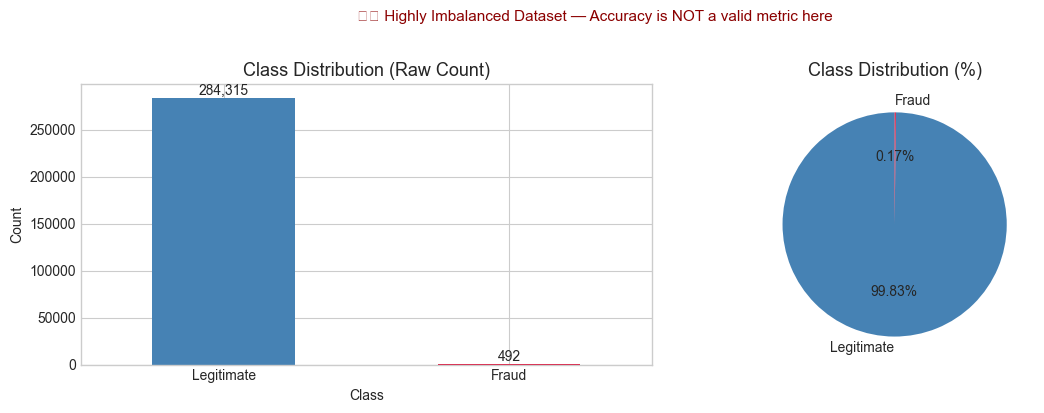

In [5]:
# ── Class imbalance visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
fraud_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'], rot=0)
axes[0].set_title('Class Distribution (Raw Count)', fontsize=13)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

# Pie chart
axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['steelblue', 'crimson'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('⚠️ Highly Imbalanced Dataset — Accuracy is NOT a valid metric here', 
             fontsize=11, color='darkred', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

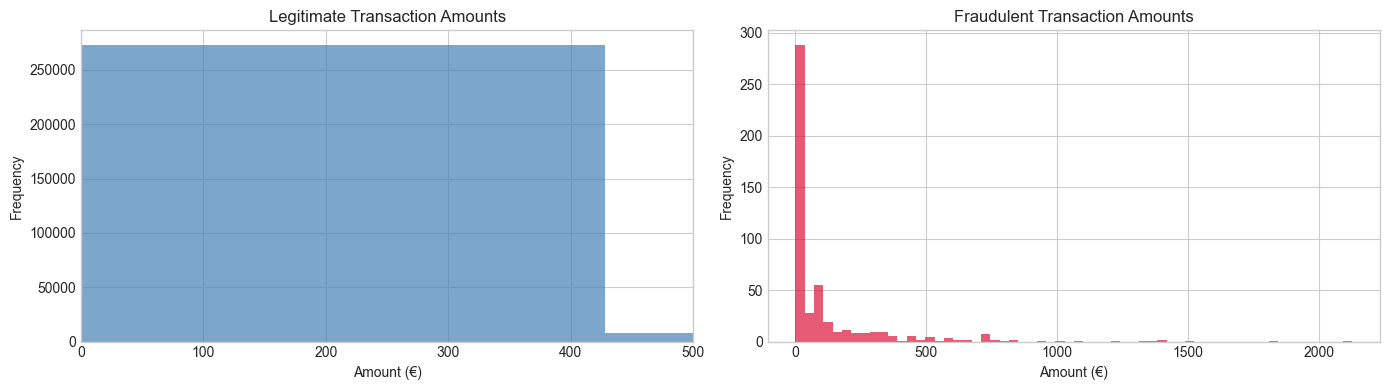

Fraud amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [6]:
# ── Transaction amount: fraud vs legitimate ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['Class'] == 0]['Amount'].plot(kind='hist', bins=60, ax=axes[0],
                                     color='steelblue', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount (€)')
axes[0].set_xlim(0, 500)  # Focus on common range

df[df['Class'] == 1]['Amount'].plot(kind='hist', bins=60, ax=axes[1],
                                     color='crimson', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.savefig('../outputs/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Fraud amount stats:')
print(df[df['Class'] == 1]['Amount'].describe())

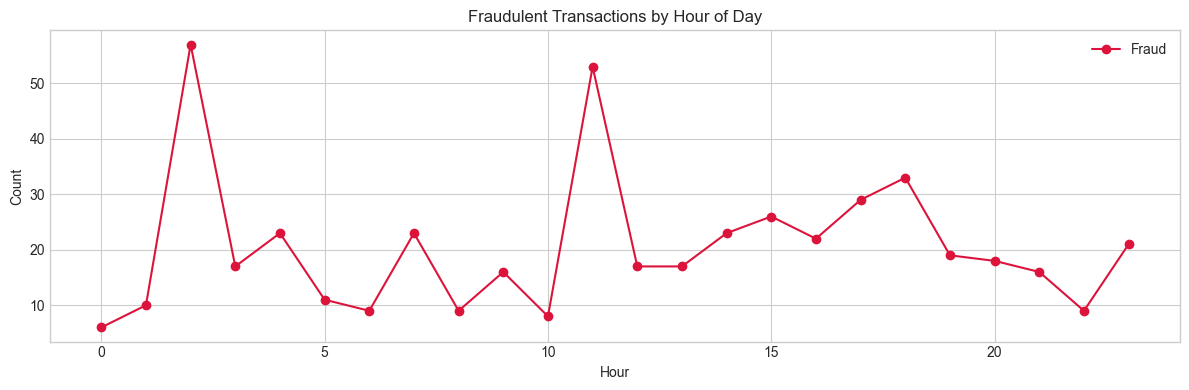

In [7]:
# ── Fraud over time ───────────────────────────────────────────────────────────
# 'Time' = seconds elapsed from first transaction in dataset
df['Hour'] = (df['Time'] / 3600).astype(int) % 24  # Convert to hour of day

fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()
legit_by_hour = df[df['Class'] == 0].groupby('Hour').size()

fig, ax = plt.subplots(figsize=(12, 4))
fraud_by_hour.plot(ax=ax, color='crimson', label='Fraud', marker='o')
ax.set_title('Fraudulent Transactions by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Preprocessing & Class Imbalance Handling

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ── Feature / target split ────────────────────────────────────────────────────
X = df.drop(columns=['Class', 'Hour'])  # Drop target and engineered col
y = df['Class']

# ── Scale Amount and Time (V1–V28 are already PCA-transformed) ────────────────
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# ── Train / test split (stratified to preserve fraud ratio) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train fraud cases: {y_train.sum()} | Test fraud cases: {y_test.sum()}')

Train: (227845, 30) | Test: (56962, 30)
Train fraud cases: 394 | Test fraud cases: 98


In [9]:
# ── Apply SMOTE to training set only ─────────────────────────────────────────
# IMPORTANT: Never apply SMOTE to test set — that would leak synthetic data into evaluation

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_res).value_counts().to_dict()}')

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


---
## 4. Model Training

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay,
                              precision_recall_curve)

# ── Helper: evaluate any model ────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')
    print(f'AUC-ROC: {auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'], ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix\nAUC: {auc:.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'../outputs/cm_{model_name.replace(" ", "_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    return auc, y_prob


  Logistic Regression
AUC-ROC: 0.9698

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



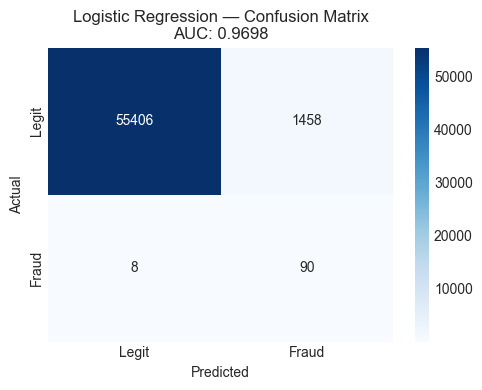

In [11]:
# ── Model 1: Logistic Regression (Baseline) ───────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
auc_lr, prob_lr = evaluate_model(lr, X_test, y_test, 'Logistic Regression')

In [12]:
# Good recall but it struggles with fraud precision. It flags too many as fraud. a 3 per cent of legit where flagged as fraud.


  Random Forest
AUC-ROC: 0.9731

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



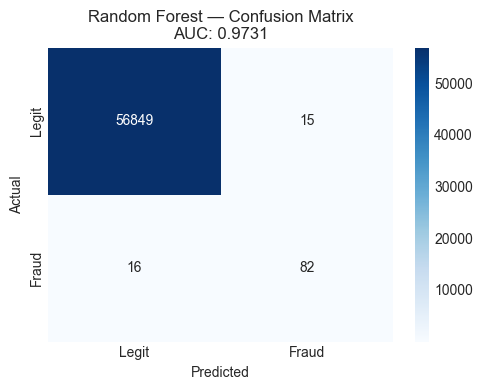

In [13]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
auc_rf, prob_rf = evaluate_model(rf, X_test, y_test, 'Random Forest')


  XGBoost
AUC-ROC: 0.9769

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



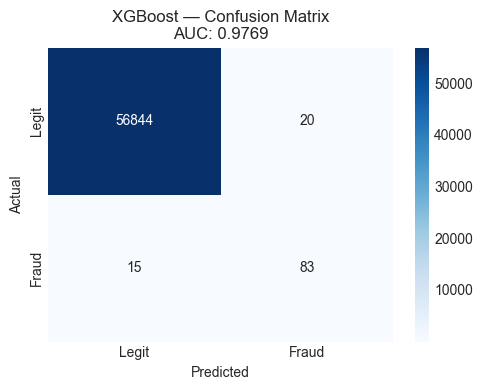

In [14]:
# ── Model 3: XGBoost (Headline Model) ────────────────────────────────────────
from collections import Counter

# Calculate imbalance ratio from your ORIGINAL (pre-SMOTE) training data
counter = Counter(y_train)  # use y_train, not y_train_res
scale = counter[0] / counter[1]  # ratio of legit to fraud

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale  # handles imbalance natively
)

# Train on ORIGINAL data, not SMOTE-resampled
xgb.fit(X_train, y_train)
auc_xgb, prob_xgb = evaluate_model(xgb, X_test, y_test, 'XGBoost')

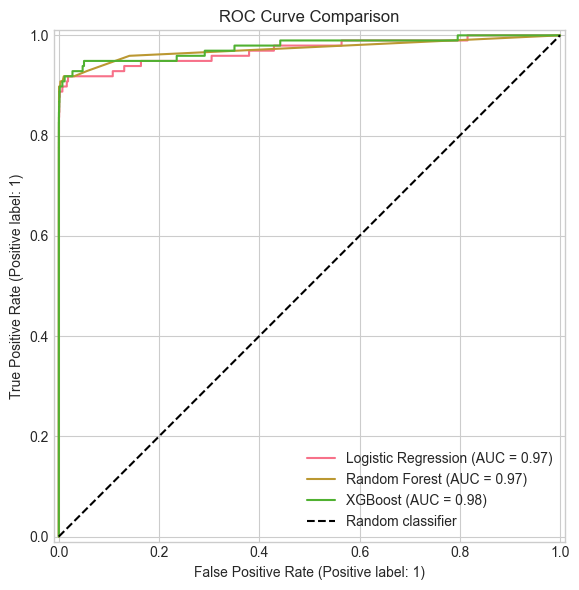

In [ ]:
# ── ROC Curve Comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for model, prob, name in [(lr, prob_lr, 'Logistic Regression'),
                           (rf, prob_rf, 'Random Forest'),
                           (xgb, prob_xgb, 'XGBoost')]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Explainability with SHAP

> In compliance-heavy fintech environments, regulators and risk teams need to understand **why** a transaction was flagged — not just that it was. SHAP provides this explainability.

In [ ]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
263020,1.388689,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.394322,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.261273
11378,-1.578646,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,-0.515765,-0.295555,0.109305,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-0.305852
147283,-0.136621,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,2.034786,-1.060151,0.016867,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.049095
219439,0.988041,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.192024,-0.281684,-0.639426,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,-0.349271
36939,-1.180778,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,0.009083,-0.164015,-0.328294,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-0.347232


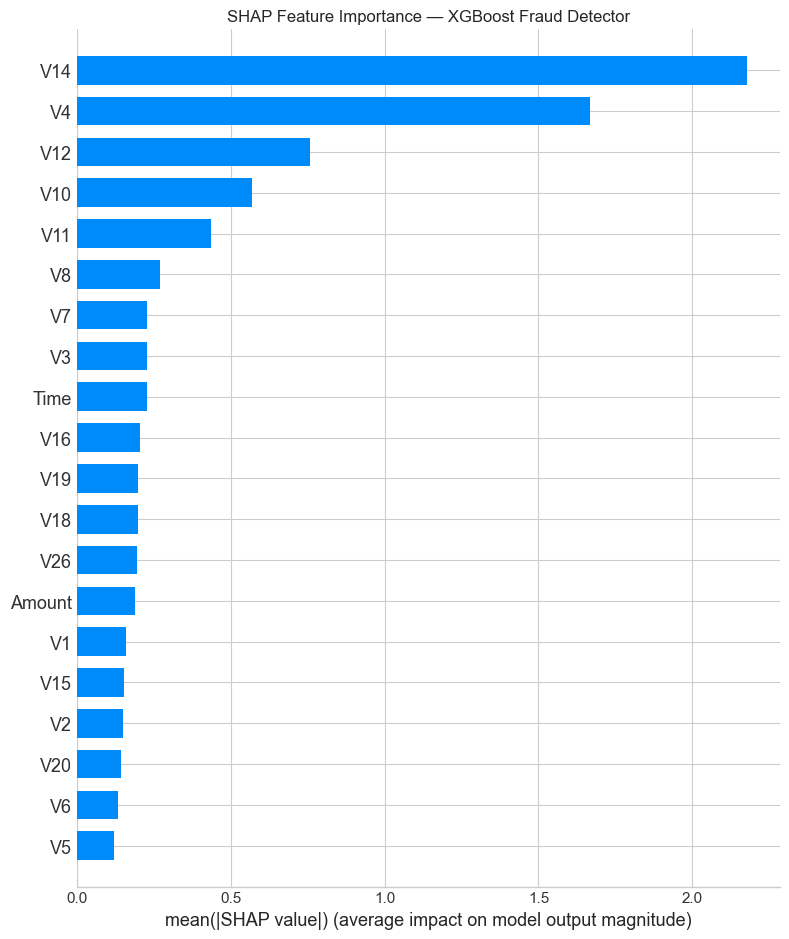

In [ ]:
import shap

# Use a sample for speed
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# ── Global feature importance ─────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost Fraud Detector')
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

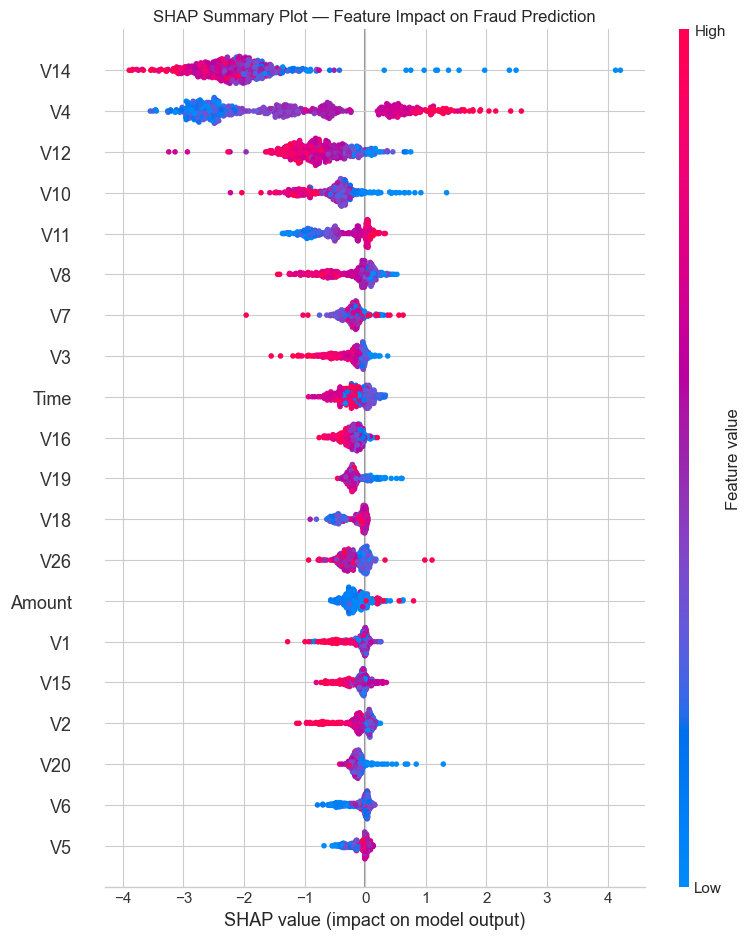

In [ ]:
# ── SHAP beeswarm — shows directionality of each feature ─────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Fraud Prediction')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Transaction #0
Fraud Probability: 0.000 → ✅ LEGITIMATE


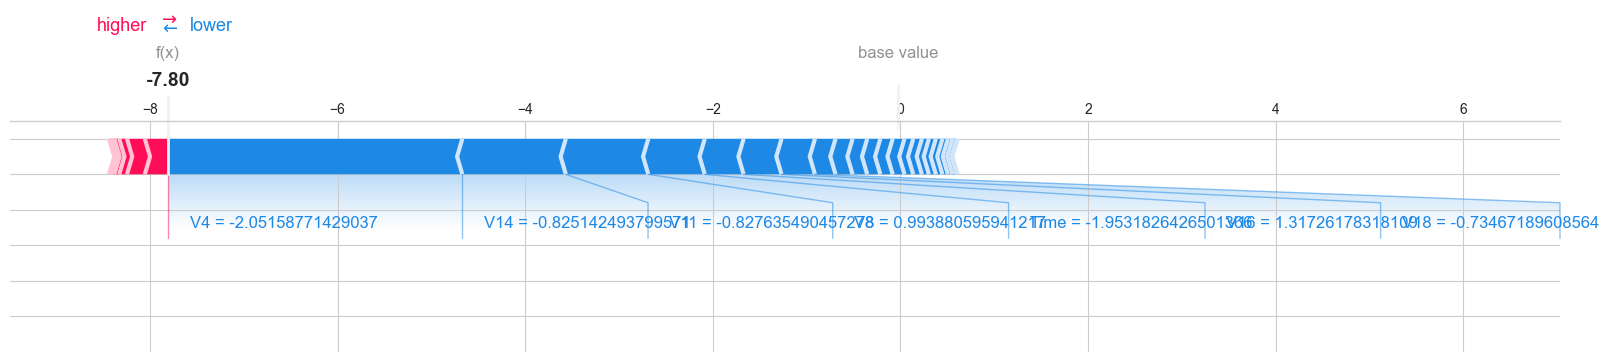

In [ ]:
# ── Explain a single transaction (use case: compliance officer review) ────────
idx = 0  # Change this to inspect different transactions
transaction = X_sample.iloc[[idx]]
fraud_prob = xgb.predict_proba(transaction)[0][1]

print(f'Transaction #{idx}')
print(f'Fraud Probability: {fraud_prob:.3f} → {"🚨 FLAGGED" if fraud_prob > 0.5 else "✅ LEGITIMATE"}')


shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    transaction,
    matplotlib=True,
    show=False
)
plt.savefig('../outputs/shap_single_transaction.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Threshold Tuning for Business Use


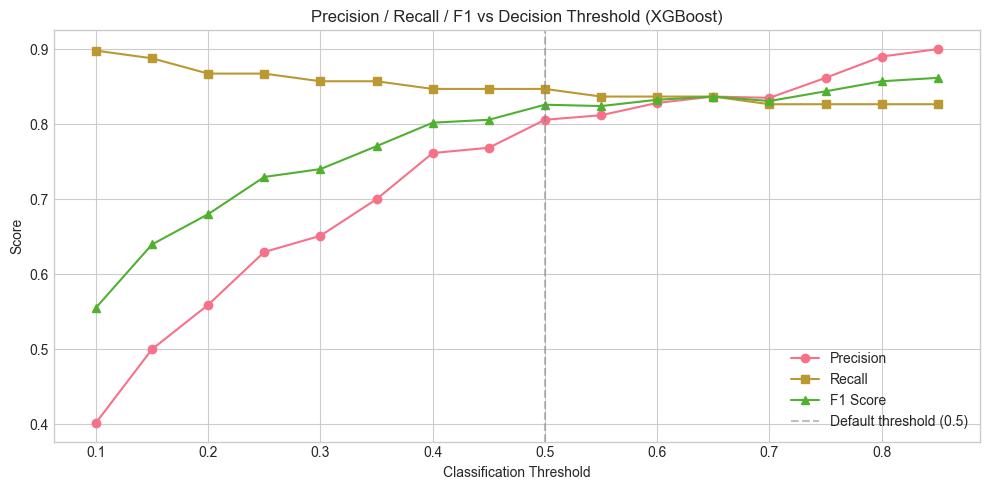


Best F1 threshold: 0.85 → F1=0.8617


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (prob_xgb >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0)
    })

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', marker='o')
ax.plot(results_df['threshold'], results_df['recall'],    label='Recall',    marker='s')
ax.plot(results_df['threshold'], results_df['f1'],        label='F1 Score',  marker='^')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold (XGBoost)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_f1_row = results_df.loc[results_df['f1'].idxmax()]
print(f'\nBest F1 threshold: {best_f1_row["threshold"]:.2f} → F1={best_f1_row["f1"]:.4f}')

In [ ]:
fraud_proba

array([9.9965048e-01, 9.9993885e-01, 9.9967229e-01, 9.8767006e-01,
       9.9983406e-01, 9.9985933e-01, 9.9989974e-01, 9.9993098e-01,
       9.9987996e-01, 9.9981707e-01, 9.2224383e-01, 2.7219093e-01,
       9.9145889e-01, 9.9992645e-01, 9.9957520e-01, 9.9992442e-01,
       9.9980503e-01, 1.7977880e-01, 9.4950682e-01, 9.9974769e-01,
       9.9973339e-01, 9.9987435e-01, 9.9235559e-01, 9.5580479e-05,
       9.9989247e-01, 9.9993408e-01, 9.9945885e-01, 9.9977809e-01,
       9.9987805e-01, 9.9921632e-01, 3.6344756e-03, 9.9860710e-01,
       9.9976450e-01, 9.9991322e-01, 1.7815912e-01, 4.3177616e-04,
       9.9617755e-01, 9.9971086e-01, 9.9979728e-01, 1.6617075e-02,
       5.1160401e-01, 9.9987364e-01, 9.9975044e-01, 9.9985278e-01,
       9.9974591e-01, 3.3380280e-04, 9.9992764e-01, 9.9993885e-01,
       9.9989414e-01, 9.9989355e-01, 9.9985039e-01, 5.7868380e-04,
       9.9989200e-01, 9.9991071e-01, 9.9992144e-01, 9.9990571e-01,
       1.1484799e-01, 9.6861994e-01, 9.9994230e-01, 9.9919444e

---
## 7. Model Summary & Conclusions

In [ ]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_rf, auc_xgb]
}).sort_values('AUC-ROC', ascending=False)

print('=== Model Comparison ===')
print(summary.to_string(index=False))

print("""
=== Key Takeaways ===
1. Accuracy is misleading on imbalanced data — always use AUC-ROC, Precision, Recall & F1
2. SMOTE improved recall on minority (fraud) class significantly
3. XGBoost achieved the best AUC-ROC — recommended for production use
4. SHAP values provide the explainability required for compliance reporting
5. Threshold tuning allows the business to balance fraud capture vs false positives

=== Next Steps (Production Roadmap) ===
- A/B test threshold settings with the fraud review team
- Retrain monthly as fraud patterns evolve
- Add real-time scoring via FastAPI endpoint
- Build monitoring dashboard for model drift detection
""")

=== Model Comparison ===
              Model  AUC-ROC
            XGBoost 0.976874
      Random Forest 0.973103
Logistic Regression 0.969848

=== Key Takeaways ===
1. Accuracy is misleading on imbalanced data — always use AUC-ROC, Precision, Recall & F1
2. SMOTE improved recall on minority (fraud) class significantly
3. XGBoost achieved the best AUC-ROC — recommended for production use
4. SHAP values provide the explainability required for compliance reporting
5. Threshold tuning allows the business to balance fraud capture vs false positives

=== Next Steps (Production Roadmap) ===
- A/B test threshold settings with the fraud review team
- Retrain monthly as fraud patterns evolve
- Add real-time scoring via FastAPI endpoint
- Build monitoring dashboard for model drift detection



In [ ]:
import os
os.makedirs('../src', exist_ok=True)


In [ ]:
import joblib
joblib.dump(xgb, '../src/xgb_fraud_model.pkl')

['../src/xgb_fraud_model.pkl']

In [ ]:
import os
print(os.getcwd())

c:\Users\franc\Desktop\DATA ANALYSIS PORTFOLIO\Fraud Detection Project


In [ ]:
import os
import joblib
os.makedirs('src', exist_ok=True)
joblib.dump(xgb, 'src/xgb_fraud_model.pkl')
print("Model saved successfully!")

Model saved successfully!
